Categorías encontradas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Cargando 403 imágenes de cardboard...
Cargando 501 imágenes de glass...
Cargando 410 imágenes de metal...
Cargando 594 imágenes de paper...
Cargando 482 imágenes de plastic...
Cargando 137 imágenes de trash...
Muestras: Train: 1515, Val: 506, Test: 506
Entrenando modelo lineal (esto puede tardar unos minutos)...


C:\Users\victo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy en Train: 0.7611
Accuracy en Validación: 0.4407
Accuracy en Test: 0.4545

Informe detallado en Test:
              precision    recall  f1-score   support

   cardboard       0.59      0.51      0.54        81
       glass       0.32      0.34      0.33       100
       metal       0.38      0.35      0.36        82
       paper       0.57      0.59      0.58       119
     plastic       0.44      0.48      0.46        97
       trash       0.41      0.33      0.37        27

    accuracy                           0.45       506
   macro avg       0.45      0.43      0.44       506
weighted avg       0.46      0.45      0.45       506



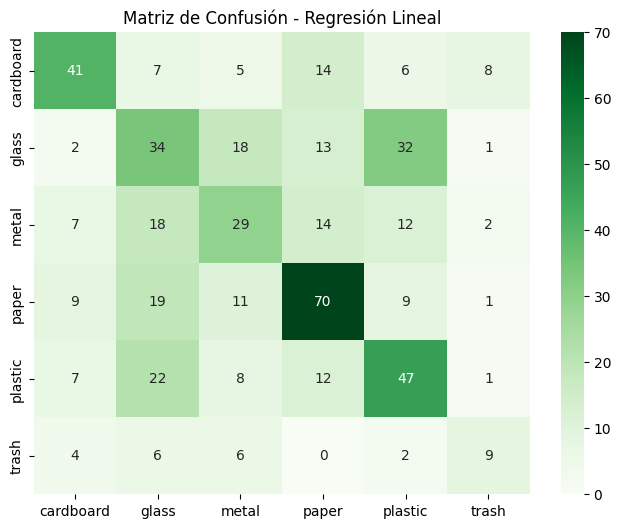

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import glob
import seaborn as sns
from PIL import Image

# Carga y preprocesamiento
PATH_DATOS = 'data/' 
IMG_SIZE = (128, 128)
def preparar_datos(path):
    X_list = []
    y_list = []
    # Obtenemos las categorías basadas en los nombres de las carpetas
    categorias = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    
    print(f"Categorías encontradas: {categorias}")
    
    for idx, cat in enumerate(categorias):
        files = glob.glob(os.path.join(path, cat, '*'))
        print(f"Cargando {len(files)} imágenes de {cat}...")
        for f in files:
            try:
                
                img = Image.open(f).convert('RGB')
                img = img.resize(IMG_SIZE)
                X_list.append(np.array(img))
                y_list.append(idx)
            except Exception as e:
                print(f"Error cargando archivo {f}: {e}")
                
    return np.array(X_list), np.array(y_list), categorias

X, y, nombres_clases = preparar_datos(PATH_DATOS)

X_flat = X.reshape(X.shape[0], -1) 

X_flat = X_flat / 255.0

# División de los datos (60% Train, 20% Val, 20% Test)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Muestras: Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Cargamos modelo lineal
model_lineal = LogisticRegression(max_iter=100,  solver='lbfgs')

print("Entrenando modelo lineal (esto puede tardar unos minutos)...")
model_lineal.fit(X_train, y_train)

# Evaluamos los resultados
def evaluar(nombre, dataset_X, dataset_y):
    preds = model_lineal.predict(dataset_X)
    acc = accuracy_score(dataset_y, preds)
    print(f"Accuracy en {nombre}: {acc:.4f}")
    return acc

acc_train = evaluar("Train", X_train, y_train)
acc_val = evaluar("Validación", X_val, y_val)
acc_test = evaluar("Test", X_test, y_test)


print("\nInforme en Test:")
print(classification_report(y_test, model_lineal.predict(X_test), target_names=nombres_clases))

# Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, model_lineal.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nombres_clases, yticklabels=nombres_clases, cmap='Greens')
plt.title("Matriz de Confusión - Regresión Lineal")
plt.show()